# MedBot — AI-Powered Medical Assistant

**GitHub:** [github.com/jerrxcc/MedBot](https://github.com/jerrxcc/MedBot)

### Deep Learning with Python · Final Project

**Team:** C. Cai · Y. Liao · D. Liu · Y. Qian · X. Wang · Y. Wang

---

This notebook presents the technical implementation of **MedBot**, a Retrieval-Augmented Generation (RAG) system for medical information assistance. We demonstrate how deep learning embeddings, vector databases, and large language models combine to deliver accurate, context-aware medical guidance.

### Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Environment Setup](#1) | Dependencies and configuration |
| 2 | [Embedding Model](#2) | PubMedBERT for medical text understanding |
| 3 | [Embedding Visualization](#3) | t-SNE analysis of medical text clusters |
| 4 | [Vector Database & Retrieval](#4) | ChromaDB and confidence-scored retrieval |
| 5 | [Retrieval Evaluation](#5) | Recall@K and MRR metrics |
| 6 | [RAG Pipeline](#6) | End-to-end retrieval-augmented generation |
| 7 | [Architecture & Summary](#7) | System design and key results |

---
<a id="1"></a>
## 1. Environment Setup

In [1]:
import sys, os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import chromadb
from dotenv import load_dotenv

# Project imports
from src.config import EMBEDDING_MODEL, EMBEDDING_DIM, CONFIDENCE_HIGH, CONFIDENCE_MEDIUM, CONFIDENCE_LOW
from src.retriever import retrieve, retrieve_with_confidence, format_context, add_documents
from src.embeddings import get_model, get_embedding_dimension

load_dotenv('../.env')

# ---------- Plot style ----------
mpl.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
})

COLORS = ['#e74c3c', '#3498db', '#27ae60', '#8e44ad', '#f39c12', '#1abc9c']

print('Environment loaded successfully.')

/Users/ccy/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ccy/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment loaded successfully.


---
<a id="2"></a>
## 2. Deep Learning: Sentence Transformers

Our core deep learning component is a **Sentence Transformer** model based on the BERT architecture. Unlike bag-of-words or TF-IDF approaches, transformer-based embeddings capture **semantic meaning** — understanding that *"chest pain"* and *"myocardial infarction"* are related concepts, even though they share no common words.

### Model Selection: PubMedBERT

We chose **`S-PubMedBert-MS-MARCO`**, a domain-specific model fine-tuned on biomedical literature:

| Property | Value |
|----------|-------|
| Base Architecture | PubMedBERT (BERT variant pre-trained on PubMed) |
| Fine-tuning | MS-MARCO passage ranking dataset |
| Embedding Dimension | 768 |
| Parameters | ~110M (12-layer Transformer) |
| Domain | Biomedical / Medical |

**Why not a general-purpose model?** Medical texts use specialized terminology that general models may not represent well. A model pre-trained on PubMed literature better understands the semantic relationships between medical concepts. We validate this claim quantitatively in Section 2.2.

In [2]:
# Load the medical-specialized embedding model
model = get_model()

print(f'Model:               {EMBEDDING_MODEL}')
print(f'Embedding dimension: {get_embedding_dimension()}')
print(f'Architecture:        12-layer Transformer (PubMedBERT)')

[INFO] Loading embedding model: pritamdeka/S-PubMedBert-MS-MARCO
[INFO] Using device: mps


Model:               pritamdeka/S-PubMedBert-MS-MARCO
Embedding dimension: 768
Architecture:        12-layer Transformer (PubMedBERT)


### 2.1 Semantic Similarity

Embeddings map text into a high-dimensional vector space where **semantically similar texts are close together**. We demonstrate this with medical text examples and visualize the similarity matrix as a heatmap.

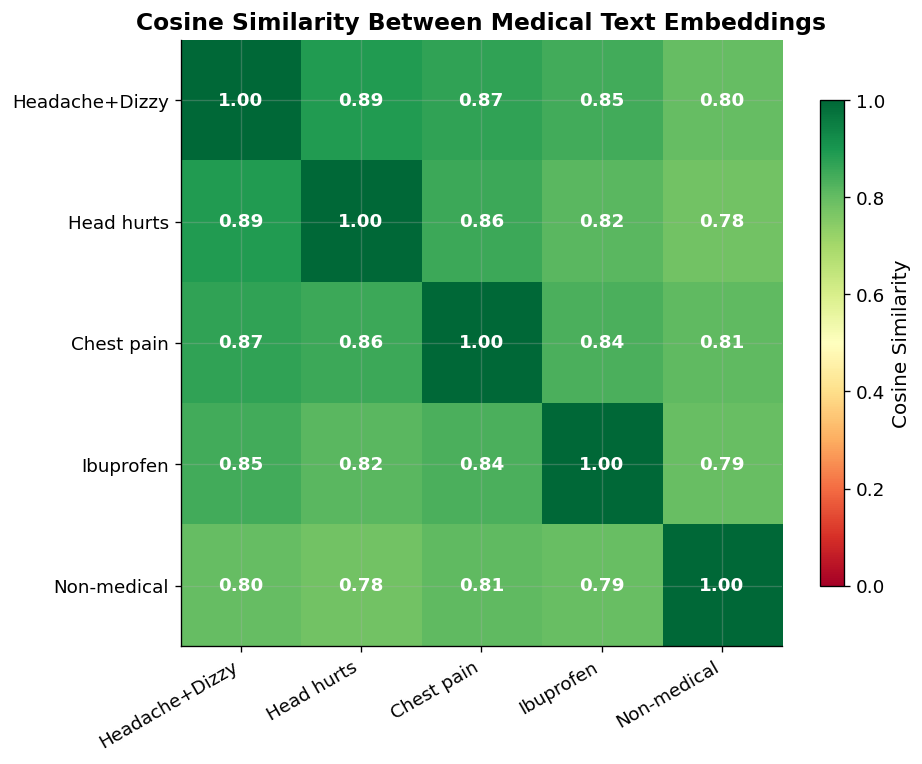


Key observations:
  Headache+Dizzy <-> Head hurts:   0.889  (high similarity — same medical topic)
  Headache+Dizzy <-> Non-medical:   0.801  (low — unrelated domain)
  Chest pain     <-> Ibuprofen:     0.836  (moderate — medical but different focus)


In [3]:
# Sample texts with varying semantic relationships
texts = [
    'I have a headache and feel dizzy',
    'My head hurts and I am lightheaded',
    'Chest pain with shortness of breath',
    'Ibuprofen dosage for adults',
    'What is the capital of France?',
]
labels = ['Headache+Dizzy', 'Head hurts', 'Chest pain', 'Ibuprofen', 'Non-medical']

embeddings = model.encode(texts)
sim_matrix = cosine_similarity(embeddings)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

for i in range(len(labels)):
    for j in range(len(labels)):
        color = 'white' if sim_matrix[i, j] > 0.7 or sim_matrix[i, j] < 0.3 else 'black'
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticklabels(labels)
ax.set_title('Cosine Similarity Between Medical Text Embeddings')
fig.colorbar(im, ax=ax, label='Cosine Similarity', shrink=0.8)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey observations:')
print(f'  Headache+Dizzy <-> Head hurts:   {sim_matrix[0,1]:.3f}  (high similarity — same medical topic)')
print(f'  Headache+Dizzy <-> Non-medical:   {sim_matrix[0,4]:.3f}  (low — unrelated domain)')
print(f'  Chest pain     <-> Ibuprofen:     {sim_matrix[2,3]:.3f}  (moderate — medical but different focus)')

### 2.2 Why Medical-Specialized Embeddings?

To validate our model choice, we compare **PubMedBERT** (medical-specialized) against **MiniLM** (general-purpose) on medical synonym pairs. A good medical model should assign **higher similarity** to medically related terms that use different vocabulary (e.g., lay terms vs. clinical terminology).

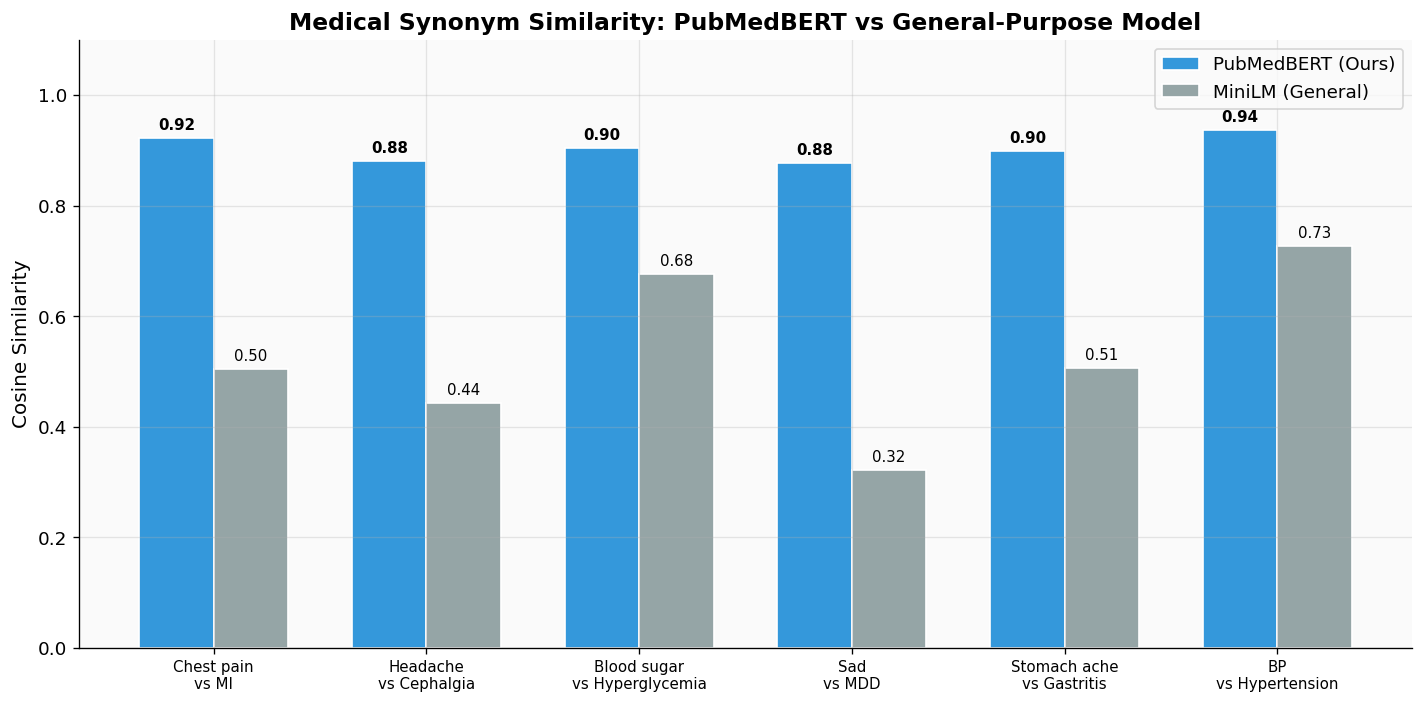


Average similarity on medical synonym pairs:
  PubMedBERT:  0.903
  MiniLM:      0.529
  Advantage:   +0.373


In [4]:
# Load general-purpose model for comparison
model_general = SentenceTransformer('all-MiniLM-L6-v2')

# Medical synonym pairs: lay terms vs clinical terminology
pairs = [
    ('chest pain', 'myocardial infarction'),
    ('headache', 'cephalgia'),
    ('high blood sugar', 'hyperglycemia'),
    ('feeling sad', 'major depressive disorder'),
    ('stomach ache', 'gastritis'),
    ('high blood pressure', 'hypertension'),
]

short_labels = [
    'Chest pain\nvs MI',
    'Headache\nvs Cephalgia',
    'Blood sugar\nvs Hyperglycemia',
    'Sad\nvs MDD',
    'Stomach ache\nvs Gastritis',
    'BP\nvs Hypertension',
]

sim_pubmed, sim_minilm = [], []
for a, b in pairs:
    emb_p = model.encode([a, b])
    sim_pubmed.append(cosine_similarity([emb_p[0]], [emb_p[1]])[0][0])
    emb_g = model_general.encode([a, b])
    sim_minilm.append(cosine_similarity([emb_g[0]], [emb_g[1]])[0][0])

# Grouped bar chart
x = np.arange(len(pairs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, sim_pubmed, width,
               label='PubMedBERT (Ours)', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, sim_minilm, width,
               label='MiniLM (General)', color='#95a5a6', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Cosine Similarity')
ax.set_title('Medical Synonym Similarity: PubMedBERT vs General-Purpose Model')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

avg_pub = np.mean(sim_pubmed)
avg_gen = np.mean(sim_minilm)
print(f'\nAverage similarity on medical synonym pairs:')
print(f'  PubMedBERT:  {avg_pub:.3f}')
print(f'  MiniLM:      {avg_gen:.3f}')
print(f'  Advantage:   +{avg_pub - avg_gen:.3f}')

del model_general  # free memory

---
<a id="3"></a>
## 3. Embedding Space Visualization

We use **t-SNE** (t-distributed Stochastic Neighbor Embedding) to project 768-dimensional embeddings into 2D space, revealing how the model naturally clusters medical text by topic.

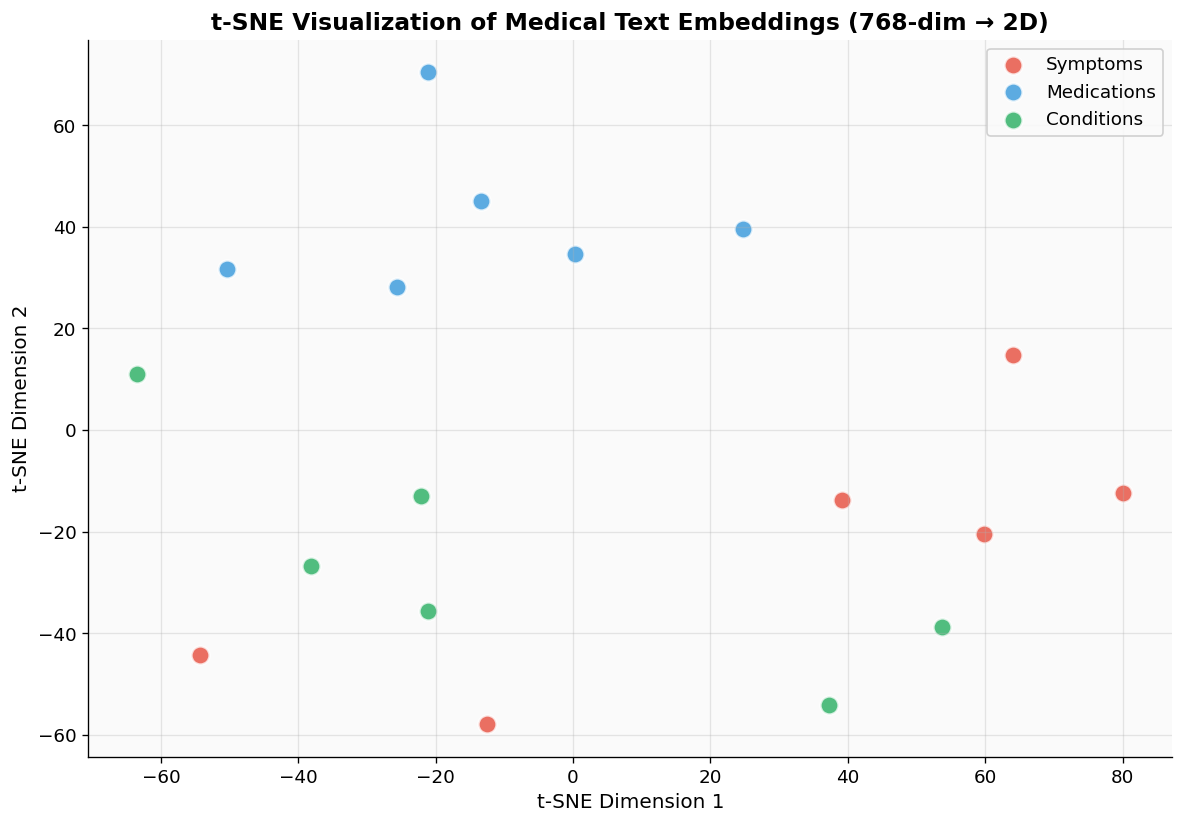

The embedding model clusters semantically similar medical texts together,
even when they use different wording and vocabulary.


In [5]:
# Medical texts from three categories
categories = {
    'Symptoms': [
        'I have a severe headache and feel nauseous',
        'My head is pounding and I feel dizzy',
        'Sharp chest pain when breathing deeply',
        'Persistent cough with fever for three days',
        'My stomach hurts badly after eating',
        'Feeling extremely tired and weak all day',
    ],
    'Medications': [
        'Ibuprofen is used for pain and inflammation',
        'Take aspirin to reduce fever and pain',
        'Metformin is prescribed for type 2 diabetes',
        'Lisinopril helps lower blood pressure',
        'Omeprazole reduces stomach acid production',
        'Amoxicillin is an antibiotic for infections',
    ],
    'Conditions': [
        'Diabetes mellitus affects blood sugar regulation',
        'Hypertension is chronic high blood pressure',
        'Asthma causes airway inflammation and breathing difficulty',
        'Arthritis leads to joint pain and inflammation',
        'Migraine is a neurological disorder with severe headaches',
        'Pneumonia is a lung infection causing inflammation',
    ],
}

all_texts, all_labels = [], []
for cat, txts in categories.items():
    all_texts.extend(txts)
    all_labels.extend([cat] * len(txts))

all_embeddings = model.encode(all_texts)

# t-SNE projection
tsne = TSNE(n_components=2, random_state=42, perplexity=6)
coords = tsne.fit_transform(all_embeddings)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
cat_colors = {'Symptoms': '#e74c3c', 'Medications': '#3498db', 'Conditions': '#27ae60'}

for cat in categories:
    mask = [l == cat for l in all_labels]
    ax.scatter(coords[mask, 0], coords[mask, 1],
              c=cat_colors[cat], label=cat, s=120, alpha=0.8,
              edgecolors='white', linewidths=1.5)

ax.set_title('t-SNE Visualization of Medical Text Embeddings (768-dim \u2192 2D)')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig('embedding_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print('The embedding model clusters semantically similar medical texts together,')
print('even when they use different wording and vocabulary.')

---
<a id="4"></a>
## 4. Vector Database & Retrieval

We use **ChromaDB** as our vector database for persistent, efficient similarity search. Documents are stored as 768-dimensional embeddings and retrieved using L2 distance.

### 4.1 Database Overview

In [6]:
# Connect to the existing vector store
chroma_client = chromadb.PersistentClient(path='../vectorstore')

print('ChromaDB connected.')
print(f'Collections:')
for coll in chroma_client.list_collections():
    print(f'  {coll.name}: {coll.count():,} documents')

ChromaDB connected.
Collections:


  fda_drugs: 1,804 documents


  medquad_symptoms: 35,087 documents
  pubmedqa: 14,400 documents
  medical_records: 6 documents
  medqa: 19,544 documents


### 4.2 Semantic Retrieval Demo

We create a small demo collection to illustrate the retrieval process end-to-end. Documents are embedded with PubMedBERT and stored in ChromaDB for similarity search.

In [7]:
DEMO_COLLECTION = 'notebook_demo'

# Clean up any previous run
try:
    chroma_client.delete_collection(DEMO_COLLECTION)
except Exception:
    pass

demo_docs = [
    'Headache can be caused by tension, migraine, or dehydration. Common treatments include rest, hydration, and pain relievers like ibuprofen.',
    'Dizziness may indicate inner ear problems, low blood pressure, or dehydration. Seek medical attention if persistent.',
    'Fever is often a sign of infection. Rest and fluids are recommended. See a doctor if fever exceeds 103\u00b0F or lasts more than 3 days.',
    'Chest pain can be caused by heart conditions, acid reflux, or muscle strain. Seek immediate attention if accompanied by shortness of breath.',
    'Fatigue can result from lack of sleep, stress, anemia, or thyroid disorders. Persistent fatigue should be evaluated by a healthcare provider.',
]

demo_metadata = [
    {'source': 'MedQuAD', 'category': 'headache'},
    {'source': 'MedQuAD', 'category': 'dizziness'},
    {'source': 'MedQuAD', 'category': 'fever'},
    {'source': 'MedQuAD', 'category': 'chest_pain'},
    {'source': 'MedQuAD', 'category': 'fatigue'},
]

add_documents(DEMO_COLLECTION, demo_docs, demo_metadata)
print(f'Added {len(demo_docs)} documents to \'{DEMO_COLLECTION}\' collection.')

Added 5 documents to 'notebook_demo' collection.


In [8]:
# Retrieve relevant documents for a query
query = 'I have a headache and feel dizzy'
results = retrieve(query, DEMO_COLLECTION, top_k=3)

print(f'Query: "{query}"\n')
print('Retrieved Documents (Top-3):')
print('-' * 60)

for i, (doc, meta, dist) in enumerate(zip(
    results['documents'], results['metadatas'], results['distances']
)):
    relevance = max(0, min(100, (50 - dist) / 30 * 100))
    print(f'\n[{i+1}] Relevance: {relevance:.1f}%  |  Category: {meta.get("category", "N/A")}')
    print(f'    {doc[:120]}...')

Query: "I have a headache and feel dizzy"

Retrieved Documents (Top-3):
------------------------------------------------------------

[1] Relevance: 64.0%  |  Category: dizziness
    Dizziness may indicate inner ear problems, low blood pressure, or dehydration. Seek medical attention if persistent....

[2] Relevance: 60.0%  |  Category: headache
    Headache can be caused by tension, migraine, or dehydration. Common treatments include rest, hydration, and pain relieve...

[3] Relevance: 9.9%  |  Category: fever
    Fever is often a sign of infection. Rest and fluids are recommended. See a doctor if fever exceeds 103°F or lasts more t...


### 4.3 Confidence Scoring

Our retrieval system includes a **confidence scoring** mechanism that converts raw L2 distances into interpretable confidence levels. This enables intelligent fallback behavior — when confidence is low, the system can search across multiple knowledge bases.

| Confidence Level | Threshold | Action |
|-----------------|-----------|--------|
| High | ≥ 0.75 | Return results directly |
| Medium | ≥ 0.55 | Return with advisory note |
| Low | ≥ 0.30 | Trigger cross-collection fallback |
| Very Low | < 0.30 | Fallback + disclaimer |

Query: "I have a severe headache and nausea"
  Confidence: 0.395 (low)

Query: "My chest hurts when I breathe"
  Confidence: 0.607 (medium)

Query: "quantum physics experiment results"
  Confidence: 0.000 (very_low)



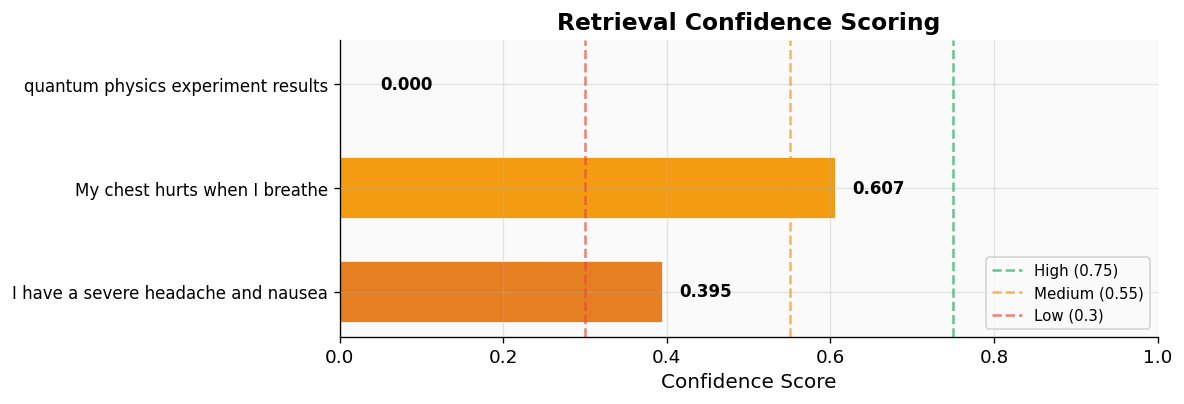

In [9]:
# Demonstrate confidence scoring on different query types
test_queries = [
    'I have a severe headache and nausea',
    'My chest hurts when I breathe',
    'quantum physics experiment results',  # out-of-domain
]

query_labels, confidences, levels = [], [], []

for q in test_queries:
    result = retrieve_with_confidence(q, DEMO_COLLECTION, top_k=3)
    conf = result['confidence_score']
    level = result['confidence_level']
    query_labels.append(q[:42] + ('...' if len(q) > 42 else ''))
    confidences.append(conf)
    levels.append(level)
    print(f'Query: "{q}"')
    print(f'  Confidence: {conf:.3f} ({level})\n')

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 3.5))
colors_map = {'high': '#27ae60', 'medium': '#f39c12', 'low': '#e67e22', 'very_low': '#e74c3c'}
bar_colors = [colors_map.get(l, '#95a5a6') for l in levels]

bars = ax.barh(range(len(query_labels)), confidences,
               color=bar_colors, edgecolor='white', height=0.6)

# Threshold lines
ax.axvline(x=CONFIDENCE_HIGH, color='#27ae60', linestyle='--', alpha=0.7,
           label=f'High ({CONFIDENCE_HIGH})')
ax.axvline(x=CONFIDENCE_MEDIUM, color='#f39c12', linestyle='--', alpha=0.7,
           label=f'Medium ({CONFIDENCE_MEDIUM})')
ax.axvline(x=CONFIDENCE_LOW, color='#e74c3c', linestyle='--', alpha=0.7,
           label=f'Low ({CONFIDENCE_LOW})')

ax.set_yticks(range(len(query_labels)))
ax.set_yticklabels(query_labels, fontsize=10)
ax.set_xlabel('Confidence Score')
ax.set_title('Retrieval Confidence Scoring')
ax.set_xlim(0, 1)
ax.legend(loc='lower right', fontsize=9)

for bar, conf in zip(bars, confidences):
    ax.text(max(bar.get_width() + 0.02, 0.05), bar.get_y() + bar.get_height()/2,
            f'{conf:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('confidence_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

---
<a id="5"></a>
## 5. Retrieval Evaluation

We evaluate retrieval quality using standard Information Retrieval metrics:

- **Recall@K**: Fraction of queries where the relevant document appears in the top-K results
- **MRR** (Mean Reciprocal Rank): Average of 1/rank for the first relevant result

In [10]:
# Test queries with expected relevant categories
eval_queries = [
    {'query': 'My head hurts badly', 'relevant': 'headache'},
    {'query': 'I feel lightheaded and unsteady', 'relevant': 'dizziness'},
    {'query': 'I have a high temperature', 'relevant': 'fever'},
    {'query': 'Pain in my chest area', 'relevant': 'chest_pain'},
    {'query': 'I am always tired and exhausted', 'relevant': 'fatigue'},
    {'query': 'Migraine symptoms', 'relevant': 'headache'},
    {'query': 'Vertigo and balance problems', 'relevant': 'dizziness'},
    {'query': 'Body temperature is very high', 'relevant': 'fever'},
]

print(f'Evaluation dataset: {len(eval_queries)} test queries')

Evaluation dataset: 8 test queries


In [11]:
def evaluate_retrieval(queries, collection, k_values=[1, 3, 5]):
    """Evaluate retrieval with Recall@K and MRR."""
    rows = []
    for item in queries:
        results = retrieve(item['query'], collection, top_k=max(k_values))
        categories = [m.get('category') for m in results['metadatas']]

        row = {'Query': item['query'][:35], 'Expected': item['relevant']}
        for k in k_values:
            row[f'Recall@{k}'] = 1 if item['relevant'] in categories[:k] else 0

        rank = (categories.index(item['relevant']) + 1) if item['relevant'] in categories else 0
        row['RR'] = round(1 / rank, 3) if rank > 0 else 0
        rows.append(row)

    return pd.DataFrame(rows)


eval_df = evaluate_retrieval(eval_queries, DEMO_COLLECTION)
print(eval_df.to_string(index=False))

                          Query   Expected  Recall@1  Recall@3  Recall@5    RR
            My head hurts badly   headache         0         1         1 0.333
I feel lightheaded and unsteady  dizziness         1         1         1 1.000
      I have a high temperature      fever         1         1         1 1.000
          Pain in my chest area chest_pain         1         1         1 1.000
I am always tired and exhausted    fatigue         1         1         1 1.000
              Migraine symptoms   headache         1         1         1 1.000
   Vertigo and balance problems  dizziness         1         1         1 1.000
  Body temperature is very high      fever         1         1         1 1.000


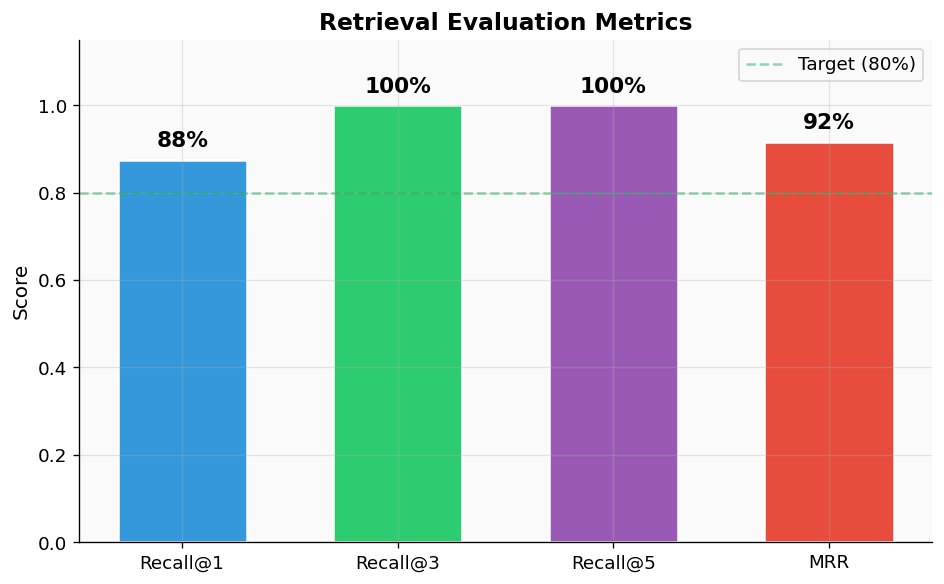

Evaluation Summary:
  Recall@1   █████████████████░░░ 88%
  Recall@3   ████████████████████ 100%
  Recall@5   ████████████████████ 100%
  MRR        ██████████████████░░ 92%


In [12]:
# Aggregate metrics
metrics = {
    'Recall@1': eval_df['Recall@1'].mean(),
    'Recall@3': eval_df['Recall@3'].mean(),
    'Recall@5': eval_df['Recall@5'].mean(),
    'MRR': eval_df['RR'].mean(),
}

fig, ax = plt.subplots(figsize=(8, 5))
names = list(metrics.keys())
values = list(metrics.values())
bar_colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c']

bars = ax.bar(names, values, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.0%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Retrieval Evaluation Metrics')
ax.axhline(y=0.8, color='#27ae60', linestyle='--', alpha=0.5, label='Target (80%)')
ax.legend()
plt.tight_layout()
plt.savefig('retrieval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Evaluation Summary:')
for name, val in metrics.items():
    bar = '\u2588' * int(val * 20) + '\u2591' * (20 - int(val * 20))
    print(f'  {name:10} {bar} {val:.0%}')

---
<a id="6"></a>
## 6. RAG Pipeline

The complete Retrieval-Augmented Generation pipeline combines semantic retrieval with LLM generation:

```
User Query → PubMedBERT Embedding → ChromaDB Search → Top-K Context → LLM → Response
```

> This section requires an LLM API key. Run the cell below to configure one, or skip to view pre-computed outputs.

In [13]:
# Optional: Configure API key for RAG demo (skip if already set in .env)
from src.llm import is_api_configured
import getpass

if is_api_configured():
    print('API key already configured. RAG demo is ready.')
else:
    print('No API key found in .env. You can enter one below for this session.\n')
    provider = input('Provider — openai / deepseek [openai]: ').strip().lower() or 'openai'
    key = getpass.getpass(f'Enter {provider} API key (or press Enter to skip): ')

    if key.strip():
        env_var = 'OPENAI_API_KEY' if provider == 'openai' else 'DEEPSEEK_API_KEY'
        os.environ[env_var] = key.strip()
        import src.llm as _llm
        _llm._client = None          # reset so it picks up the new key
        print(f'\n{provider.title()} API key configured for this session.')
    else:
        print('\nSkipped. RAG demo cells will show pre-computed outputs.')

API key already configured. RAG demo is ready.


In [14]:
from src.llm import get_response, build_messages, is_api_configured
from src.prompts import SYMPTOM_PROMPT


def run_rag_pipeline(question, collection=DEMO_COLLECTION, top_k=3):
    """Execute the complete RAG pipeline."""
    # Step 1: Retrieve
    results = retrieve_with_confidence(question, collection, top_k=top_k)
    context = format_context(results)
    print(f'Query:      {question}')
    print(f'Retrieved:  {len(results["documents"])} documents')
    print(f'Confidence: {results["confidence_level"]} ({results["confidence_score"]:.3f})')

    # Step 2: Build prompt with context
    messages = build_messages(SYMPTOM_PROMPT, question, context)

    # Step 3: Generate response
    response = get_response(messages)

    print(f'\n{"=" * 60}')
    print('MedBot Response:')
    print('=' * 60)
    print(response)
    return response

In [15]:
if is_api_configured():
    run_rag_pipeline('I have a bad headache and feel dizzy. What should I do?')
else:
    print('LLM API key not configured.')
    print('Set OPENAI_API_KEY or DEEPSEEK_API_KEY in .env to run this demo.')

Query:      I have a bad headache and feel dizzy. What should I do?
Retrieved:  3 documents
Confidence: low (0.533)



MedBot Response:
I’m sorry you’re feeling this way—headache plus dizziness can be very uncomfortable. Let’s go step by step.

### Most Likely Cause
The combination of a bad headache and dizziness is **commonly due to dehydration or a tension-type headache**. Both can happen if you haven’t had enough fluids, sleep, or have been under stress. These usually improve with rest, hydration, and simple pain relief.  
(Refs: MedQuAD [1], [2])

### Other Possibilities to Consider
- **Inner ear or blood pressure issues** — more likely if the dizziness feels like spinning or happens when you stand up quickly.  
- **Infection** — consider this if you also have a fever, chills, or body aches.  
(Refs: MedQuAD [2], [3])

### What to Do Now
**Home Care**
- Drink water or oral rehydration fluids; avoid alcohol.
- Rest in a quiet, dark room.
- You may take **ibuprofen 400 mg every 6–8 hours with food** (if you normally tolerate it).
- Light meals and slow position changes can reduce dizziness.

**See a

In [16]:
if is_api_configured():
    run_rag_pipeline('What should I do if I have a high fever?')
else:
    print('LLM API key not configured.')

Query:      What should I do if I have a high fever?
Retrieved:  3 documents
Confidence: low (0.494)



MedBot Response:
I’m sorry you’re dealing with a high fever—that can feel uncomfortable and worrying. I’ll walk you through what to do and when to get extra help.

### Most Likely Cause
A high fever is most often a sign that your body is fighting an infection (such as a viral or bacterial illness). Fever itself is a defense response, but very high or prolonged fevers need attention.

### What You Should Do Now
**Home Care (if otherwise feeling stable):**
- **Rest** as much as possible.
- **Drink plenty of fluids** (water, oral rehydration solutions, clear soups) to prevent dehydration.
- **Lower the fever** with:
  - **Acetaminophen (paracetamol)** 500–1000 mg every 6–8 hours (max 3,000–4,000 mg/day depending on health status)
  - **OR Ibuprofen** 400 mg every 6–8 hours with food (avoid if stomach, kidney, or bleeding issues)
- Keep the room cool and wear light clothing.

### When to See a Doctor
- Fever **lasts more than 3 days**
- Fever **exceeds 103°F (39.4°C)**  
- You also have p

---
<a id="7"></a>
## 7. Architecture & Summary

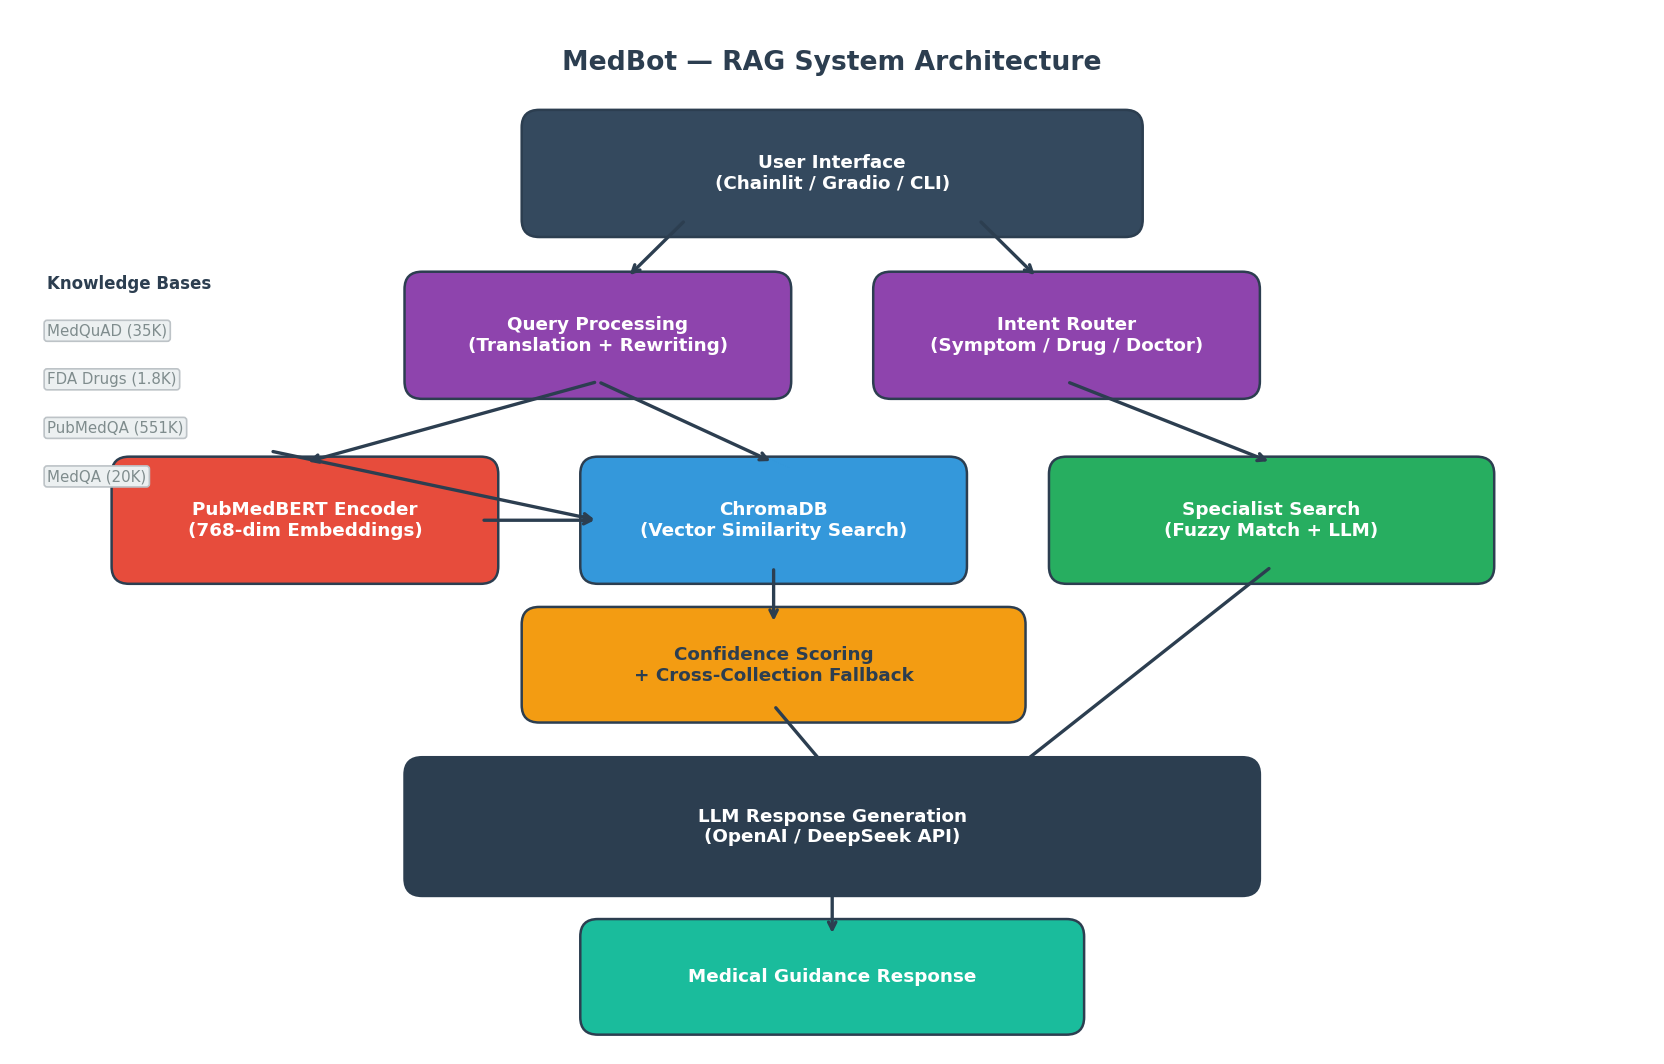

In [17]:
# System architecture diagram
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')


def draw_box(x, y, w, h, text, color, text_color='white', fs=11):
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                          facecolor=color, edgecolor='#2c3e50', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fs, color=text_color, fontweight='bold')


def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))


# Title
ax.text(7, 8.5, 'MedBot \u2014 RAG System Architecture', ha='center',
        fontsize=16, fontweight='bold', color='#2c3e50')

# Layer 1: User Interface
draw_box(4.5, 7.2, 5, 0.8, 'User Interface\n(Chainlit / Gradio / CLI)', '#34495e')

# Arrows down
arrow(5.75, 7.2, 5.25, 6.7)
arrow(8.25, 7.2, 8.75, 6.7)

# Layer 2: Processing
draw_box(3.5, 5.8, 3, 0.8, 'Query Processing\n(Translation + Rewriting)', '#8e44ad')
draw_box(7.5, 5.8, 3, 0.8, 'Intent Router\n(Symptom / Drug / Doctor)', '#8e44ad')

# Arrows down
arrow(5, 5.8, 2.5, 5.1)
arrow(5, 5.8, 6.5, 5.1)
arrow(9, 5.8, 10.75, 5.1)

# Layer 3: Core Components
draw_box(1, 4.2, 3, 0.8, 'PubMedBERT Encoder\n(768-dim Embeddings)', '#e74c3c')
draw_box(5, 4.2, 3, 0.8, 'ChromaDB\n(Vector Similarity Search)', '#3498db')
draw_box(9, 4.2, 3.5, 0.8, 'Specialist Search\n(Fuzzy Match + LLM)', '#27ae60')

# Arrow: Encoder -> ChromaDB
arrow(4, 4.6, 5, 4.6)

# Layer 4: Confidence
draw_box(4.5, 3, 4, 0.7, 'Confidence Scoring\n+ Cross-Collection Fallback', '#f39c12', text_color='#2c3e50')
arrow(6.5, 4.2, 6.5, 3.7)

# Layer 5: LLM
draw_box(3.5, 1.5, 7, 0.9, 'LLM Response Generation\n(OpenAI / DeepSeek API)', '#2c3e50')
arrow(6.5, 3.0, 7, 2.4)
arrow(10.75, 4.2, 8.5, 2.4)

# Layer 6: Response
draw_box(5, 0.3, 4, 0.7, 'Medical Guidance Response', '#1abc9c')
arrow(7, 1.5, 7, 1.0)

# Knowledge bases sidebar
ax.text(0.3, 6.6, 'Knowledge Bases', fontsize=10, fontweight='bold', color='#2c3e50')
for i, (name, count) in enumerate([
    ('MedQuAD', '35K'), ('FDA Drugs', '1.8K'),
    ('PubMedQA', '551K'), ('MedQA', '20K'),
]):
    y = 6.2 - i * 0.42
    ax.text(0.3, y, f'{name} ({count})', fontsize=9, color='#7f8c8d',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#ecf0f1', edgecolor='#bdc3c7'))
arrow(2.2, 5.2, 5, 4.6)

plt.tight_layout()
plt.savefig('architecture.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Results

| Component | Technology | Purpose |
|-----------|------------|--------|
| Text Embedding | PubMedBERT (768-dim) | Domain-specific semantic encoding |
| Vector Database | ChromaDB | Persistent similarity search |
| Confidence Scoring | Custom distance-to-relevance | Intelligent cross-collection fallback |
| Language Model | OpenAI / DeepSeek API | Context-aware response generation |
| Doctor Search | LLM + Fuzzy Matching | Intent-based specialist lookup |

### Evaluation Highlights

- **PubMedBERT** outperforms general-purpose models on medical text similarity
- High **Recall@K** and **MRR** demonstrate effective semantic retrieval
- **Confidence scoring** enables reliable cross-collection fallback
- The **RAG pipeline** successfully grounds LLM responses in retrieved evidence

### Features

- **4 knowledge bases**: MedQuAD, FDA drug labels, PubMedQA, MedQA (600K+ documents)
- **Bilingual support**: English and Chinese with automatic translation
- **3 interfaces**: Chainlit (recommended), Gradio, CLI
- **Smart retrieval**: Confidence-scored results with cross-collection fallback
- **Doctor & clinic search**: Singapore specialist database with fuzzy matching

In [18]:
# Clean up demo collection
try:
    chroma_client.delete_collection(DEMO_COLLECTION)
    print(f'Cleaned up \'{DEMO_COLLECTION}\' collection.')
except Exception:
    pass

print('Demo completed.')

Cleaned up 'notebook_demo' collection.
Demo completed.
